**Setup toàn bộ môi trường + dataset + code**

In [1]:
# =========================================================
# CELL 1 - FULL SETUP COLAB
# =========================================================
# ===== ĐI VỀ /kaggle/working =====
%cd /kaggle/working
# ===== CHECK GPU =====
import torch

print("=" * 50)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("=" * 50)

# =========================================================
# CLONE GITHUB
# =========================================================

!git clone -b TN_B_ON https://github.com/ThongLuc2k3/Prompt-Guided-XRay-Segmentation.git

# =========================================================
# DOWNLOAD DATASET ZIP TỪ GOOGLE DRIVE
# =========================================================

!gdown --id 1X1SY8T63pdBPIdrv_3P0gKVwoLxCa5sW

# =========================================================
# UNZIP DATASET
# =========================================================

!unzip -oq dataset_BTXRD.zip

# =========================================================
# KIỂM TRA DATASET
# =========================================================

print("\nDATASET STRUCTURE:")
!ls dataset_BTXRD

# =========================================================
# COPY DATASET VÀO PROJECT
# =========================================================

!mv dataset_BTXRD Prompt-Guided-XRay-Segmentation/

# =========================================================
# ĐI VÀO PROJECT
# =========================================================

%cd Prompt-Guided-XRay-Segmentation

# =========================================================
# INSTALL REQUIREMENTS
# =========================================================

!pip install -q tqdm opencv-python matplotlib scikit-image gdown scipy

print("\nSETUP DONE!")

/kaggle/working
CUDA: True
GPU: Tesla T4
Cloning into 'Prompt-Guided-XRay-Segmentation'...
remote: Enumerating objects: 186, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 186 (delta 64), reused 88 (delta 35), pack-reused 62 (from 1)
Receiving objects: 100% (186/186), 36.63 MiB | 33.52 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1X1SY8T63pdBPIdrv_3P0gKVwoLxCa5sW
From (redirected): https://drive.google.com/uc?id=1X1SY8T63pdBPIdrv_3P0gKVwoLxCa5sW&confirm=t&uuid=eb560f1c-1a09-4e10-a5d8-1e54c4008e0b
To: /kaggle/working/dataset_BTXRD.zip
100%|███████████████████████████████████████| 1.40G/1.40G [00:12<00:00, 108MB/s]

DATASET STRUCTURE:

**Overwrite train.py**

In [2]:
%%writefile /kaggle/working/Prompt-Guided-XRay-Segmentation/train.py

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import logging
import datetime

from dataset import BTXRD_Dataset
from models.networks.prompt_unet_2D import PGA_UNet

# =========================================================
# CẤU HÌNH – chỉ đổi ở đây khi chuyển thí nghiệm
# =========================================================
EXPERIMENT         = 'B'     # 'A' → zoom_out only | 'B' → mixed_7_3
USE_ENCODER_PROMPT = True    # True để bật PromptSpatialGate ở encoder
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 4
EPOCHS     = 100
LR         = 1e-4
IMG_SIZE   = 256
EARLY_STOP = 15

# =========================================================
# METRICS
# =========================================================
def dice_loss(pred, target, smooth=1e-5):
    pred_soft    = torch.sigmoid(pred)
    intersection = (pred_soft * target).sum(dim=(1, 2, 3))
    union        = pred_soft.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return (1 - ((2. * intersection + smooth) / (union + smooth))).mean()


def batch_metrics_sum(pred, target, smooth=1e-5):
    pred_bin = (torch.sigmoid(pred) > 0.5).float()
    tp = (pred_bin * target).sum(dim=(1, 2, 3))
    fp = (pred_bin * (1 - target)).sum(dim=(1, 2, 3))
    fn = ((1 - pred_bin) * target).sum(dim=(1, 2, 3))
    dice      = (2. * tp + smooth) / (2. * tp + fp + fn + smooth)
    iou       = (tp + smooth) / (tp + fp + fn + smooth)
    precision = tp / (tp + fp + smooth)
    recall    = tp / (tp + fn + smooth)
    return dice.sum().item(), iou.sum().item(), precision.sum().item(), recall.sum().item()


def calculate_cbl(pred, target, smooth=1e-6):
    """
    CBL – Center-Based Localization score [0, 1].
    Đo tâm predicted mask có gần tâm GT mask không.
    Normalize theo đường chéo GT bbox để scale-invariant.
    Trả về (cbl_sum, valid_count).
    """
    B, _, H, W = pred.shape
    pred_bin = (torch.sigmoid(pred) > 0.5).float()

    ys = torch.arange(H, device=pred.device, dtype=torch.float32)
    xs = torch.arange(W, device=pred.device, dtype=torch.float32)
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')  # (H, W)

    cbl_sum, valid_count = 0.0, 0

    for b in range(B):
        gt_m   = target[b, 0]
        pred_m = pred_bin[b, 0]
        gt_area = gt_m.sum()

        if gt_area < smooth:
            continue  # GT rỗng → bỏ qua

        # Tâm GT
        cx_gt = (grid_x * gt_m).sum() / (gt_area + smooth)
        cy_gt = (grid_y * gt_m).sum() / (gt_area + smooth)

        # Đường chéo GT bbox
        nz    = gt_m.nonzero()
        gt_diag = torch.sqrt(
            ((nz[:, 0].max() - nz[:, 0].min()).float()) ** 2 +
            ((nz[:, 1].max() - nz[:, 1].min()).float()) ** 2
        ) + smooth

        pred_area = pred_m.sum()
        if pred_area < smooth:
            valid_count += 1  # CBL = 0 cho sample này
            continue

        # Tâm predicted mask
        cx_p = (grid_x * pred_m).sum() / (pred_area + smooth)
        cy_p = (grid_y * pred_m).sum() / (pred_area + smooth)

        d   = torch.sqrt((cx_p - cx_gt) ** 2 + (cy_p - cy_gt) ** 2)
        cbl = torch.clamp(1.0 - d / gt_diag, min=0.0)
        cbl_sum += cbl.item()
        valid_count += 1

    return cbl_sum, valid_count


# =========================================================
# LOGGER
# =========================================================
def setup_logger(exp_name):
    os.makedirs("logs", exist_ok=True)
    t = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    logging.basicConfig(
        level=logging.INFO, format='%(message)s',
        handlers=[
            logging.FileHandler(f"logs/train_exp{exp_name}_{t}.log", encoding='utf-8'),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger()


# =========================================================
# MAIN
# =========================================================
def main():
    logger = setup_logger(EXPERIMENT)
    logger.info("=" * 90)
    logger.info(f"Thí nghiệm {EXPERIMENT} | Device: {DEVICE} | EncoderPrompt: {USE_ENCODER_PROMPT}")
    logger.info("=" * 90)

    # ── Dataset ──────────────────────────────────────────────────────
    train_mode = 'zoom_out' if EXPERIMENT == 'A' else 'mixed_7_3'

    train_ds = BTXRD_Dataset(
        image_dir="dataset_BTXRD/train/images",
        json_dir="dataset_BTXRD/train/annotations",
        img_size=IMG_SIZE, is_train=True,
        prompt_mode=train_mode
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)

    # Val loaders: Exp A → 1 loader; Exp B → 3 loaders
    val_cfg = {'zoom_out': 'zoom_out'} if EXPERIMENT == 'A' else {
        'zoom_out':  'zoom_out',
        'shift':     'shift',
        'mixed_7_3': 'mixed_7_3',
    }
    val_loaders = {}
    for name, mode in val_cfg.items():
        ds = BTXRD_Dataset(
            image_dir="dataset_BTXRD/val/images",
            json_dir="dataset_BTXRD/val/annotations",
            img_size=IMG_SIZE, is_train=False,
            prompt_mode=mode
        )
        val_loaders[name] = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                                       num_workers=2, pin_memory=True)

    # ── Model ────────────────────────────────────────────────────────
    model = PGA_UNet(in_channels=1, n_classes=1,
                     use_encoder_prompt=USE_ENCODER_PROMPT).to(DEVICE)
    criterion_bce = nn.BCEWithLogitsLoss()
    optimizer     = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler     = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5)

    os.makedirs("checkpoints", exist_ok=True)
    best_val_dice   = 0.0
    patience_counter = 0
    ckpt_prefix     = f"checkpoints/pga_unet_exp{EXPERIMENT}"

    for epoch in range(EPOCHS):
        # ── Train ────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
        for images, masks, prompts in loop:
            images, masks, prompts = (images.to(DEVICE), masks.to(DEVICE), prompts.to(DEVICE))
            preds = model(images, prompts)
            loss  = criterion_bce(preds, masks) + dice_loss(preds, masks)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
            loop.set_postfix(loss=f"{loss.item():.4f}")

        train_loss_avg = train_loss / len(train_loader)

        # ── Validate (tất cả loaders) ─────────────────────────────
        model.eval()
        val_results = {}
        with torch.no_grad():
            for vname, vloader in val_loaders.items():
                s_dice, s_iou, s_pre, s_rec = 0, 0, 0, 0
                s_cbl, n_cbl, n_total = 0, 0, 0
                for vi, vm, vp in vloader:
                    vi, vm, vp = vi.to(DEVICE), vm.to(DEVICE), vp.to(DEVICE)
                    vout = model(vi, vp)
                    d, i, p, r = batch_metrics_sum(vout, vm)
                    s_dice += d; s_iou += i; s_pre += p; s_rec += r
                    cb, ncb = calculate_cbl(vout, vm)
                    s_cbl += cb; n_cbl += ncb
                    n_total += vi.size(0)
                val_results[vname] = {
                    'dice': s_dice / n_total,
                    'iou':  s_iou  / n_total,
                    'pre':  s_pre  / n_total,
                    'rec':  s_rec  / n_total,
                    'cbl':  s_cbl  / n_cbl if n_cbl > 0 else 0.0,
                }

        # Dùng zoom_out dice làm tiêu chí chính
        primary_dice = val_results['zoom_out']['dice']
        scheduler.step(primary_dice)

        # Log
        log_str = f"Epoch {epoch+1:3d} | T_Loss: {train_loss_avg:.4f}"
        for vname, vr in val_results.items():
            tag = vname.upper()[:7]
            log_str += (f" | [{tag}] Dice:{vr['dice']:.4f} IoU:{vr['iou']:.4f}"
                        f" CBL:{vr['cbl']:.4f}")
        log_str += f" | LR:{optimizer.param_groups[0]['lr']:.1e}"

        torch.save(model.state_dict(), f"{ckpt_prefix}_last.pth")

        if primary_dice > best_val_dice:
            best_val_dice = primary_dice
            torch.save(model.state_dict(), f"{ckpt_prefix}_best.pth")
            log_str = "🥇 [BEST] " + log_str
            patience_counter = 0
        else:
            patience_counter += 1

        logger.info(log_str)

        if patience_counter >= EARLY_STOP:
            logger.info(f"Early stopping ở epoch {epoch+1}.")
            break

    logger.info(f"\nBest Dice (zoom_out): {best_val_dice:.4f}")
    logger.info(f"Checkpoint: {ckpt_prefix}_best.pth")


if __name__ == "__main__":
    main()

Overwriting /kaggle/working/Prompt-Guided-XRay-Segmentation/train.py


**Train**

In [3]:
# =========================================================
# TRAIN
# =========================================================

!python train.py

Thí nghiệm B | Device: cuda | EncoderPrompt: True
Epoch 1/100 [Train]: 100%|███████| 462/462 [01:12<00:00,  6.41it/s, loss=1.2740]
🥇 [BEST] Epoch   1 | T_Loss: 1.3610 | [ZOOM_OU] Dice:0.5815 IoU:0.4486 CBL:0.7761 | [SHIFT] Dice:0.5777 IoU:0.4439 CBL:0.7712 | [MIXED_7] Dice:0.5819 IoU:0.4490 CBL:0.7771 | LR:1.0e-04
Epoch 2/100 [Train]: 100%|███████| 462/462 [01:08<00:00,  6.79it/s, loss=1.1132]
🥇 [BEST] Epoch   2 | T_Loss: 1.2092 | [ZOOM_OU] Dice:0.5822 IoU:0.4332 CBL:0.8621 | [SHIFT] Dice:0.5722 IoU:0.4215 CBL:0.8219 | [MIXED_7] Dice:0.5801 IoU:0.4309 CBL:0.8510 | LR:1.0e-04
Epoch 3/100 [Train]: 100%|███████| 462/462 [01:07<00:00,  6.87it/s, loss=0.9925]
🥇 [BEST] Epoch   3 | T_Loss: 1.1110 | [ZOOM_OU] Dice:0.5905 IoU:0.4389 CBL:0.8979 | [SHIFT] Dice:0.5827 IoU:0.4308 CBL:0.8589 | [MIXED_7] Dice:0.5880 IoU:0.4362 CBL:0.8854 | LR:1.0e-04
Epoch 4/100 [Train]: 100%|███████| 462/462 [01:07<00:00,  6.82it/s, loss=1.1301]
🥇 [BEST] Epoch   4 | T_Loss: 1.0355 | [ZOOM_OU] Dice:0.7089 IoU:0.5704 

## Bước 2 – Thí nghiệm A (baseline sạch, zoom-out only)
# Trong train.py: EXPERIMENT='A', USE_ENCODER_PROMPT=False

Model loaded from: checkpoints/pga_unet_expB_best.pth

  ĐÁNH GIÁ 3 KỊCH BẢN  |  encoder_prompt = ON
  [100% Zoom-out]  232 samples – xong.
  [100% Shift]  232 samples – xong.
  [Mixed 70-30]  232 samples – xong.

Kịch bản           Dice↑    IoU↑    Pre↑    Rec↑    HD95↓    CBL↑     N
--------------------------------------------------------------------
100% Zoom-out     0.8395  0.7312  0.8081  0.8909     5.82  0.9454   232
100% Shift        0.8034  0.6816  0.7847  0.8428     7.43  0.9166   232
Mixed 70-30       0.8297  0.7179  0.8034  0.8756     6.29  0.9365   232


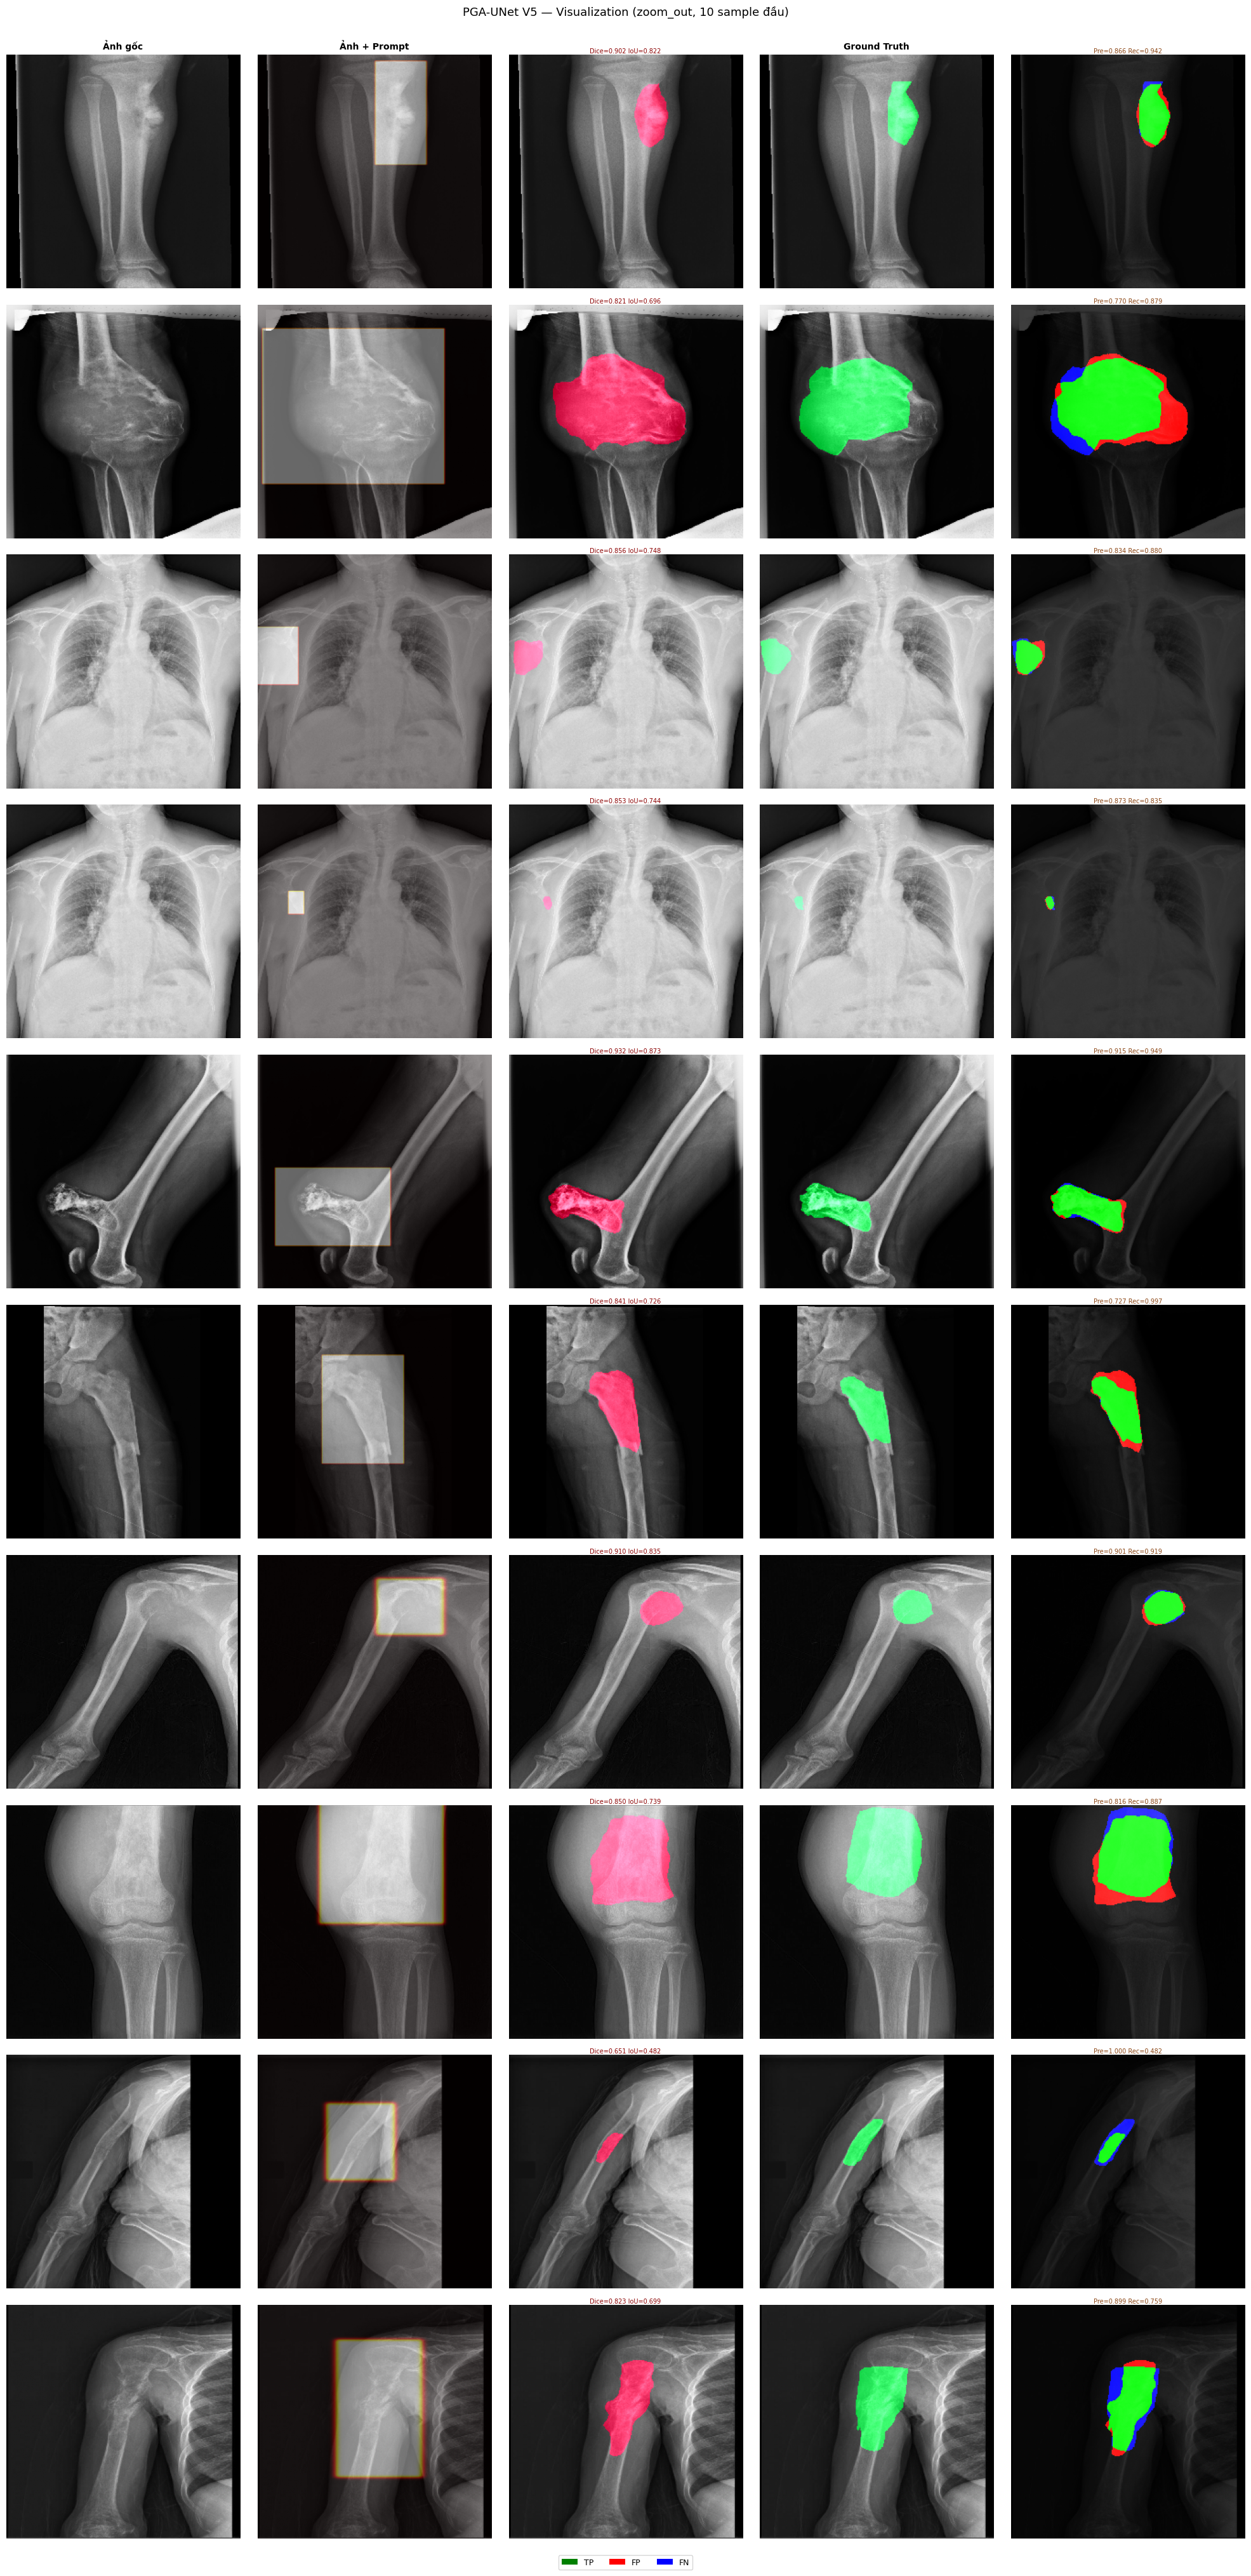

In [4]:
# @title
"""
test_exp_scenarios.py
=====================
Đánh giá 3 kịch bản prompt: 100% zoom-out | 100% shift | mixed 70-30
Visualize danh sách ảnh: mỗi ảnh hiện 2 kịch bản (zoom-out và shift)

Cách chạy:
    python test_exp_scenarios.py
"""

import os
import cv2
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from scipy.ndimage import binary_erosion, distance_transform_edt

from dataset import BTXRD_Dataset
from models.networks.prompt_unet_2D import PGA_UNet

# =========================================================
# CẤU HÌNH – chỉnh tại đây
# =========================================================
DEVICE             = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH         = "checkpoints/pga_unet_expB_best.pth"
IMG_SIZE           = 256
BATCH_SIZE         = 4
USE_ENCODER_PROMPT = True   # ← True = bật encoder gate / False = tắt

TEST_IMAGE_DIR = "dataset_BTXRD/test/images"
TEST_JSON_DIR  = "dataset_BTXRD/test/annotations"


# =========================================================
# METRIC HELPERS & POST-PROCESSING
# =========================================================

def extract_lcc(binary_map: np.ndarray) -> np.ndarray:
    if binary_map.sum() == 0:
        return binary_map
    mask_uint8 = binary_map.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    if num_labels <= 1:
        return binary_map
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest_label).astype(np.float32)

def calc_hd95(pred: np.ndarray, gt: np.ndarray) -> float:
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() and not gt.any():
        return 0.0
    if not pred.any() or not gt.any():
        return float(IMG_SIZE)
    pe = pred ^ binary_erosion(pred)
    ge = gt   ^ binary_erosion(gt)
    d1 = distance_transform_edt(~ge)[pe]
    d2 = distance_transform_edt(~pe)[ge]
    if not len(d1) or not len(d2):
        return float(IMG_SIZE)
    return float(max(np.percentile(d1, 95), np.percentile(d2, 95)))

def calc_cbl(pred_bin: np.ndarray, gt_bin: np.ndarray):
    if gt_bin.sum() == 0:
        return None
    ys, xs = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max() - ys.min()) ** 2 +
                      (xs.max() - xs.min()) ** 2) + 1e-6
    if pred_bin.sum() == 0:
        return 0.0
    yp, xp = np.where(pred_bin)
    d = np.sqrt((xp.mean() - xs.mean()) ** 2 +
                (yp.mean() - ys.mean()) ** 2)
    return float(np.clip(1.0 - d / gt_diag, 0.0, 1.0))

def get_centroid(binary_map: np.ndarray):
    if binary_map.sum() == 0:
        return None, None
    ys, xs = np.where(binary_map)
    return float(xs.mean()), float(ys.mean())

# =========================================================
# ĐÁNH GIÁ 1 KỊCH BẢN
# =========================================================

def run_eval(model: torch.nn.Module, prompt_mode: str) -> dict:
    ds = BTXRD_Dataset(
        image_dir=TEST_IMAGE_DIR,
        json_dir=TEST_JSON_DIR,
        img_size=IMG_SIZE,
        is_train=False,
        prompt_mode=prompt_mode,
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    smooth = 1e-5
    all_dice, all_iou, all_pre, all_rec, all_hd95, all_cbl = [], [], [], [], [], []

    model.eval()
    with torch.no_grad():
        for images, masks, prompts in loader:
            images  = images.to(DEVICE)
            masks   = masks.to(DEVICE)
            prompts = prompts.to(DEVICE)
            preds   = (torch.sigmoid(model(images, prompts)) > 0.5).float()

            for b in range(images.size(0)):
                pm = preds[b, 0].cpu().numpy()
                gm = masks[b, 0].cpu().numpy()
                pm = extract_lcc(pm)

                tp = (pm * gm).sum()
                fp = (pm * (1 - gm)).sum()
                fn = ((1 - pm) * gm).sum()

                all_dice.append((2 * tp + smooth) / (2 * tp + fp + fn + smooth))
                all_iou.append( (tp + smooth) / (tp + fp + fn + smooth))
                all_pre.append( (tp + smooth) / (tp + fp + smooth))
                all_rec.append( (tp + smooth) / (tp + fn + smooth))
                all_hd95.append(calc_hd95(pm.astype(bool), gm.astype(bool)))

                cbl = calc_cbl(pm.astype(bool), gm.astype(bool))
                if cbl is not None:
                    all_cbl.append(cbl)

    return {
        'dice': np.mean(all_dice),
        'iou':  np.mean(all_iou),
        'pre':  np.mean(all_pre),
        'rec':  np.mean(all_rec),
        'hd95': np.mean(all_hd95),
        'cbl':  np.mean(all_cbl) if all_cbl else 0.0,
        'n':    len(all_dice),
    }

# =========================================================
# ĐÁNH GIÁ 3 KỊCH BẢN
# =========================================================

def evaluate_all(model: torch.nn.Module) -> dict:
    enc_tag = 'ON' if USE_ENCODER_PROMPT else 'OFF'
    print("\n" + "=" * 72)
    print(f"  ĐÁNH GIÁ 3 KỊCH BẢN  |  encoder_prompt = {enc_tag}")
    print("=" * 72)

    scenarios = {
        '100% Zoom-out': 'zoom_out',
        '100% Shift':    'shift',
        'Mixed 70-30':   'mixed_7_3',
    }

    results = {}
    for name, mode in scenarios.items():
        results[name] = run_eval(model, mode)
        print(f"  [{name}]  {results[name]['n']} samples – xong.")

    header = (f"\n{'Kịch bản':<16} {'Dice↑':>7} {'IoU↑':>7} "
              f"{'Pre↑':>7} {'Rec↑':>7} {'HD95↓':>8} {'CBL↑':>7} {'N':>5}")
    print(header)
    print("-" * 68)
    for name, r in results.items():
        print(f"{name:<16} {r['dice']:>7.4f} {r['iou']:>7.4f} "
              f"{r['pre']:>7.4f} {r['rec']:>7.4f} "
              f"{r['hd95']:>8.2f} {r['cbl']:>7.4f} {r['n']:>5}")
    return results

# =========================================================
# LOAD MODEL
# =========================================================
model = PGA_UNet(use_encoder_prompt=USE_ENCODER_PROMPT).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f"Model loaded from: {MODEL_PATH}")

# =========================================================
# ĐÁNH GIÁ 3 KỊCH BẢN — in bảng số liệu
# =========================================================
results = evaluate_all(model)

# =========================================================
# VISUALIZATION — 10 sample đầu theo thứ tự (zoom_out)
# =========================================================
from IPython.display import display as _ipy_display
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from torch.utils.data import DataLoader
from dataset import BTXRD_Dataset

N_SHOW  = 10
_vis_dl = DataLoader(
    BTXRD_Dataset(TEST_IMAGE_DIR, TEST_JSON_DIR, img_size=IMG_SIZE, is_train=False, prompt_mode="zoom_out"),
    batch_size=1, shuffle=False, num_workers=0)

fig, axes = plt.subplots(N_SHOW, 5, figsize=(20, 4 * N_SHOW))
fig.suptitle("PGA-UNet V5 — Visualization (zoom_out, 10 sample đầu)", fontsize=13, y=1.001)
for ax, ct in zip(axes[0], ["Ảnh gốc", "Ảnh + Prompt", "Dự đoán", "Ground Truth", "TP/FP/FN"]):
    ax.set_title(ct, fontsize=10, fontweight="bold")

model.eval()
count = 0
with torch.no_grad():
    for _img, _gt, _hm in _vis_dl:
        if count >= N_SHOW: break
        img_np  = (_img[0,0].cpu().numpy() * 0.5 + 0.5)
        hm_np   = _hm[0,0].cpu().numpy()
        gt_np   = (_gt[0,0].cpu().numpy() > 0.5).astype(float)
        prob_np = torch.sigmoid(model(_img.to(DEVICE), _hm.to(DEVICE)))[0,0].cpu().numpy()
        pred_np = (prob_np > 0.5).astype(float)

        tp=(pred_np*gt_np).sum(); fp=(pred_np*(1-gt_np)).sum(); fn=((1-pred_np)*gt_np).sum(); e=1e-6
        dice=float((2*tp+e)/(2*tp+fp+fn+e)); iou=float((tp+e)/(tp+fp+fn+e))
        pre=float((tp+e)/(tp+fp+e));         rec=float((tp+e)/(tp+fn+e))

        row = axes[count]
        bg  = np.stack([img_np]*3, axis=-1)

        row[0].imshow(img_np, cmap="gray", vmin=0, vmax=1)
        row[0].set_ylabel(f"#{count+1} Dice={dice:.3f}", fontsize=8)

        row[1].imshow(img_np, cmap="gray", vmin=0, vmax=1)
        row[1].imshow(hm_np, cmap="hot", alpha=0.4, vmin=0, vmax=1)

        pr_ov = bg.copy()
        pr_ov[...,0] = np.clip(pr_ov[...,0] + pred_np*0.55, 0, 1)
        pr_ov[...,1] = np.clip(pr_ov[...,1] - pred_np*0.2,  0, 1)
        row[2].imshow(pr_ov)
        row[2].set_title(f"Dice={dice:.3f} IoU={iou:.3f}", fontsize=7, color="darkred", pad=2)

        gt_ov = bg.copy()
        gt_ov[...,1] = np.clip(gt_ov[...,1] + gt_np*0.55, 0, 1)
        gt_ov[...,0] = np.clip(gt_ov[...,0] - gt_np*0.2,  0, 1)
        row[3].imshow(gt_ov)

        inter = bg.copy() * 0.25
        inter[...,1] = np.clip(inter[...,1] + pred_np*gt_np*0.9,     0, 1)
        inter[...,0] = np.clip(inter[...,0] + pred_np*(1-gt_np)*1.0, 0, 1)
        inter[...,2] = np.clip(inter[...,2] + (1-pred_np)*gt_np*1.0, 0, 1)
        row[4].imshow(inter)
        row[4].set_title(f"Pre={pre:.3f} Rec={rec:.3f}", fontsize=7, color="saddlebrown", pad=2)

        for ax in row: ax.axis("off")
        count += 1

fig.legend(handles=[Patch(facecolor="green",label="TP"),Patch(facecolor="red",label="FP"),Patch(facecolor="blue",label="FN")],
           loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5,-0.01))
plt.tight_layout()
_ipy_display(fig)
plt.close(fig)
